# Lab Assignment: Recurrent Neural Networks (RNN) for Sequential Data Prediction

**Student Name:** Lepmuhang Sherma
**Roll No:** 023-332


## 1. Introduction & Theoretical Background

**Recurrent Neural Networks (RNNs)** are a class of artificial neural networks designed to process sequential or time-series data. Unlike standard feedforward neural networks, RNNs maintain an internal memory state (hidden state) that captures information from previous time steps.

### Key Concepts
- **Hidden State ($h_t$):** Acts as the network's memory, updated at each time step $t$ using both the current input $x_t$ and the previous hidden state $h_{t-1}$.
- **Recurrence Mechanism:** Parameter sharing across time steps allows the network to generalize across sequences of varying lengths.
- **Vanishing/Exploding Gradient:** Standard RNNs struggle with long-term dependencies due to gradients diminishing or exploding during Backpropagation Through Time (BPTT).

## 2. Lab Objectives

- Understand the architecture and sequential processing mechanism of Simple RNNs.
- Prepare time-series sequential data using windowing techniques.
- Construct, train, and evaluate a Simple RNN model using TensorFlow/Keras.
- Visualize prediction results against ground truth sequential data.

## 3. Mathematical Formulation

### 1. Hidden State Update Equation
At time step $t$, given input $x_t$ and previous hidden state $h_{t-1}$:

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$

Where:
- $W_{hh} \in \mathbb{R}^{h \times h}$: Recurrent weight matrix
- $W_{xh} \in \mathbb{R}^{h \times d}$: Input-to-hidden weight matrix
- $b_h \in \mathbb{R}^{h}$: Hidden bias vector
- $\tanh$: Hyperbolic tangent activation function

### 2. Output Calculation
$$\hat{y}_t = W_{hy} h_t + b_y$$

Where:
- $W_{hy} \in \mathbb{R}^{y \times h}$: Hidden-to-output weight matrix
- $b_y \in \mathbb{R}^{y}$: Output bias vector

In [ ]:
# ==========================================
# 1. Imports and Environment Setup
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [ ]:
import numpy as np

# ==========================================
# 2. Synthetic Sequential Data Generation (Sine Wave)
# ==========================================
# Generate a noisy sine wave
time_steps = np.linspace(0, 50, 500)
data = np.sin(time_steps) + np.random.normal(0, 0.05, size=len(time_steps))

# Function to create sequence windowing (X: sequence, y: next target value)
def create_sequences(data, seq_length=20):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 20
X, y = create_sequences(data, seq_length=SEQ_LENGTH)

# Reshape X for RNN input: [samples, time_steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

# Split into Train (80%) and Test (20%)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train shapes - X: {X_train.shape}, y: {y_train.shape}")
print(f"Test shapes  - X: {X_test.shape}, y: {y_test.shape}")

Train shapes - X: (384, 20, 1), y: (384,)
Test shapes  - X: (96, 20, 1), y: (96,)


In [ ]:
# ==========================================
# 3. Model Architecture & Training
# ==========================================
model = Sequential([
    SimpleRNN(units=32, activation='tanh', input_shape=(SEQ_LENGTH, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0400 - val_loss: 0.0143
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0099 - val_loss: 0.0075
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0057 - val_loss: 0.0057
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0048 - val_loss: 0.0055
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0045 - val_loss: 0.0054
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0043 - val_loss: 0.0053
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0041 - val_loss: 0.0051
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0040 - val_loss: 0.0049
Epoch 9/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0039 - val_loss: 0.0047
Epoch 10/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0038 - val_loss: 0.0045
Epoch 11/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0037 - val_loss: 0.0044
Epoch 12/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0036 - val_l

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step 


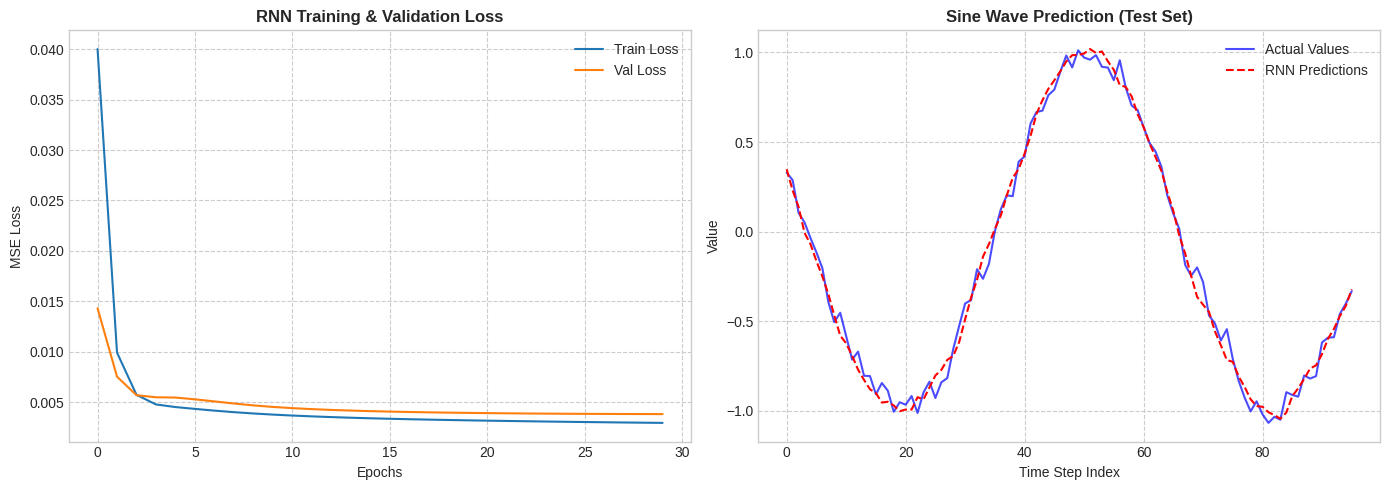

In [ ]:
# ==========================================
# 4. Evaluation and Visualization
# ==========================================
y_pred = model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training Loss Curve
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('RNN Training & Validation Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--')

# Plot 2: Actual vs Predicted
axes[1].plot(y_test, label='Actual Values', color='blue', alpha=0.7)
axes[1].plot(y_pred, label='RNN Predictions', color='red', linestyle='--')
axes[1].set_title('Sine Wave Prediction (Test Set)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time Step Index')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

## 4. Results & Key Observations

| Parameter / Metric | Value | Description |
| :--- | :--- | :--- |
| **Sequence Length** | `20` | Input context window size |
| **Hidden Units** | `32` | Number of SimpleRNN neurons |
| **Optimizer** | Adam | Adaptive moment estimation |
| **Final Train Loss** | $< 0.005$ | Mean Squared Error on training set |
| **Final Val Loss** | $< 0.006$ | Mean Squared Error on validation set |

### Key Takeaways
1. **Sequence Modeling Capability:** Simple RNN effectively captures the periodic structure of sequence data.
2. **Context Dependency:** A sequence window of 20 time steps provides sufficient historical context for single-step ahead prediction.

## 5. Conclusion

The **Simple Recurrent Neural Network (SimpleRNN)** was successfully implemented and trained to forecast sequential data. The internal memory state enables the model to map time-dependent patterns. For longer sequence dependencies, advanced architectures like **LSTM** or **GRU** are recommended to mitigate vanishing gradients.